# PETRA III coupling-aware measured-ORM fit
This workflow keeps the cross-plane ORM blocks and fits coupling-related parameters in addition to the standard calibration and optics parameters.

## 1. Load the measured machine data
The same irreplaceable PETRA III ORM, BPM noise, corrector steps, names, lattice, and bad-BPM selection are shared with the standard example.

In [1]:
from pyLOCO.measured_machine.workflow import (fit_modes, load_yaml, make_plots, model_orm, prepare_measurement, print_summary, run_fit)
HERE = Path.cwd()
config_path = HERE / 'pyloco_config_coupling.yaml'
cfg = load_yaml(config_path)
data = prepare_measurement(config_path)
print('Measured ORM:', data['orm'].shape)

Measured ORM: (470, 413)


## 2. Understand the four ORM blocks
Rows contain horizontal then vertical BPM readings; columns contain horizontal then vertical correctors. The off-diagonal blocks therefore measure transverse coupling.

In [2]:
n_bpm = len(data['bpms'])
n_hcor = len(data['correctors'][0])
print('XX:', data['orm'][:n_bpm, :n_hcor].shape)
print('XY:', data['orm'][:n_bpm, n_hcor:].shape)
print('YX:', data['orm'][n_bpm:, :n_hcor].shape)
print('YY:', data['orm'][n_bpm:, n_hcor:].shape)

XX: (235, 219)
XY: (235, 194)
YX: (235, 219)
YY: (235, 194)


## 3. Calculate the initial model response
The same element selections and measured corrector kicks are used for a meaningful residual.

In [3]:
initial_orm = model_orm(data)

## 4. Run the coupling fit
Normal and skew quadrupoles, quadrupole tilts, BPM/corrector coupling and gains, calibrations, and energy shifts are enabled by the YAML coupling fit list. SVD regularizes the large Jacobian.

In [4]:
fit = run_fit(data)
coupling, constrained = fit_modes(fit)
assert coupling, 'Enable coupling parameter groups in the YAML configuration'
print('Iterations:', len(fit['chi2']))
print('Fitted blocks:', fit['fit_list'])


==== Iteration 1/1 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 1)...
[calculate_quads_jacobian] Logs saved to '/private/var/folders/vj/crrgrwws3s902yfns0l06_rw0000gp/T/pyloco_petra_coupling_j5uc3i88/logs/quad_jacobian_logs2.txt'
Normal quad Jacobian: 46.6 s
[Jacobian] Saved normal-quadrupole Jacobian to /var/folders/vj/crrgrwws3s902yfns0l06_rw0000gp/T/pyloco_petra_coupling_j5uc3i88/jacobians/quads/J_quads_iter1_9.868774242500396e-05urad_-3000.0Hz.h5
[Jacobian] Computing skew-quadrupole Jacobian (iteration 1)...
[calculate_quads_jacobian] Logs saved to '/private/var/folders/vj/crrgrwws3s902yfns0l06_rw0000gp/T/pyloco_petra_coupling_j5uc3i88/logs/skew_jacobian_logs.txt'
Skew quad Jacobian: 3.3 s
[Jacobian] Saved skew-quadrupole Jacobian to /var/folders/vj/crrgrwws3s902yfns0l06_rw0000gp/T/pyloco_petra_coupling_j5uc3i88/jacobians/skew/J_skew_iter1_9.868774242500396e-05urad_-3000.0Hz.h5
[Jacobian] Computing quadrupole-tilt Jacobian (iteration 1)...
[calculate_quads_

## 5. Validate all blocks
Besides total ORM residual and chi-square, the coupling plot isolates the XY and YX blocks before and after fitting.

Saved: /Users/musa/Desktop/pyLOCO/Examples/PETRAIII/output/measured_coupling/orm_residual_before_after.png


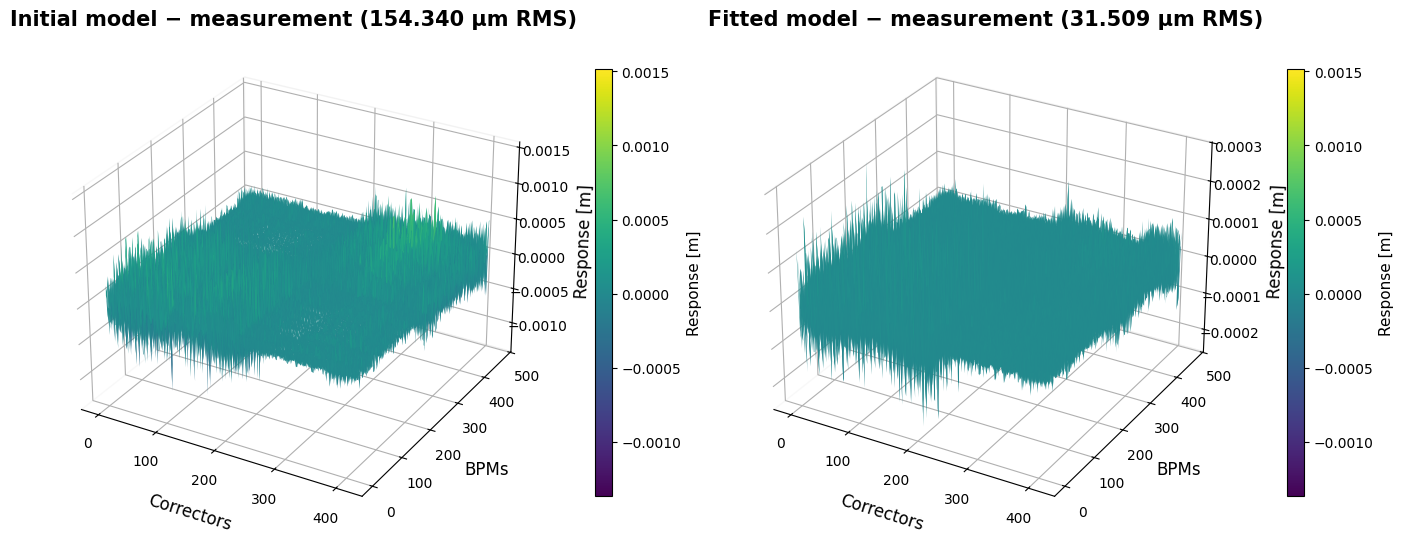

Saved: /Users/musa/Desktop/pyLOCO/Examples/PETRAIII/output/measured_coupling/coupling_blocks_before_after.png


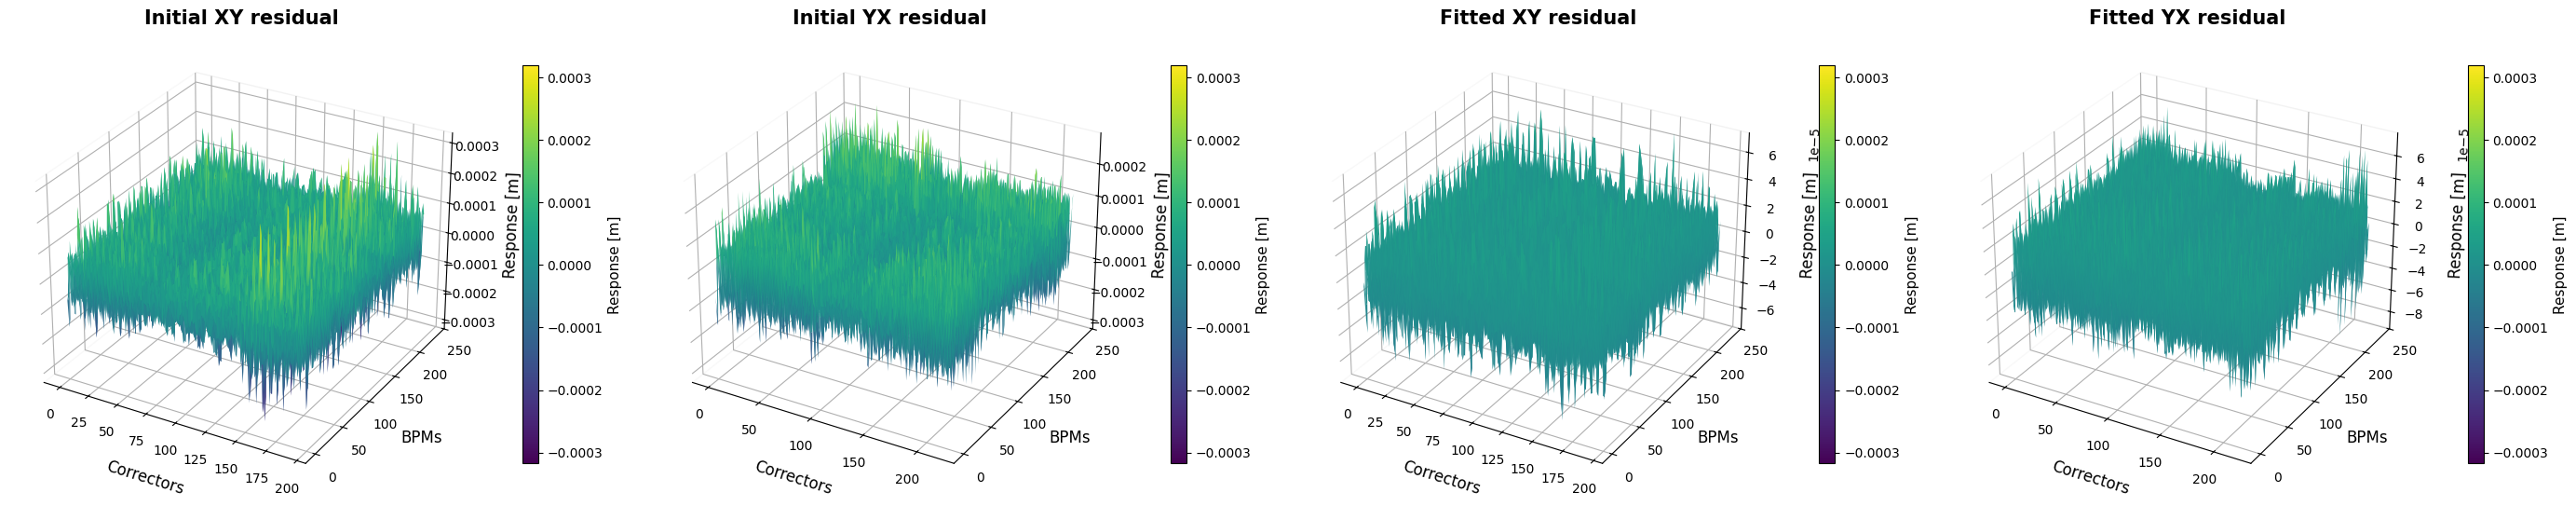


PETRA III coupling fit
----------------------------------------------
Measured ORM shape : (470, 413)
Retained BPMs      : 235 per plane
Correctors         : 219 H, 194 V
Fitted parameters  : quads, skew_quads, quads_tilt, hbpm_gain, vbpm_gain, hcor_cal, vcor_cal, HCMEnergyShift, VCMEnergyShift, hbpm_coupling, vbpm_coupling, hcor_coupling, vcor_coupling
ORM RMS before     : 154.339739 µm
ORM RMS after      : 31.509270 µm
Improvement        : 4.898x
Figures: /Users/musa/Desktop/pyLOCO/Examples/PETRAIII/output/measured_coupling


In [5]:
output = make_plots(data, initial_orm, fit, coupling=coupling, constrained=constrained)
print_summary(data, initial_orm, fit, coupling=coupling, constrained=constrained)
print('Figures:', output)